In [1]:
import numpy as np
import matplotlib.pyplot as plt
import librosa
import librosa.display
from scipy.fft import fft, fftfreq
from pydub import AudioSegment, silence

/usr/local/lib/python3.12/dist-packages/pydub/utils.py:300: SyntaxWarning: invalid escape sequence '\('
  m = re.match('([su]([0-9]{1,2})p?) \(([0-9]{1,2}) bit\)$', token)
/usr/local/lib/python3.12/dist-packages/pydub/utils.py:301: SyntaxWarning: invalid escape sequence '\('
  m2 = re.match('([su]([0-9]{1,2})p?)( \(default\))?$', token)
/usr/local/lib/python3.12/dist-packages/pydub/utils.py:310: SyntaxWarning: invalid escape sequence '\('
  elif re.match('(flt)p?( \(default\))?$', token):
/usr/local/lib/python3.12/dist-packages/pydub/utils.py:314: SyntaxWarning: invalid escape sequence '\('
  elif re.match('(dbl)p?( \(default\))?$', token):


In [2]:
audio_file = "/content/pianos-by-jtwayne-7-174717.mp3"
sr = 16000
n_fft = 1024
hop_length = 256
sentence = "the piano plays beautiful melodies every day"
words = sentence.split()

# STFT AND SPECTROGRAM

In [3]:
signal, sr = librosa.load(audio_file, sr=sr)
duration = len(signal)/sr
time = np.linspace(0, duration, len(signal))

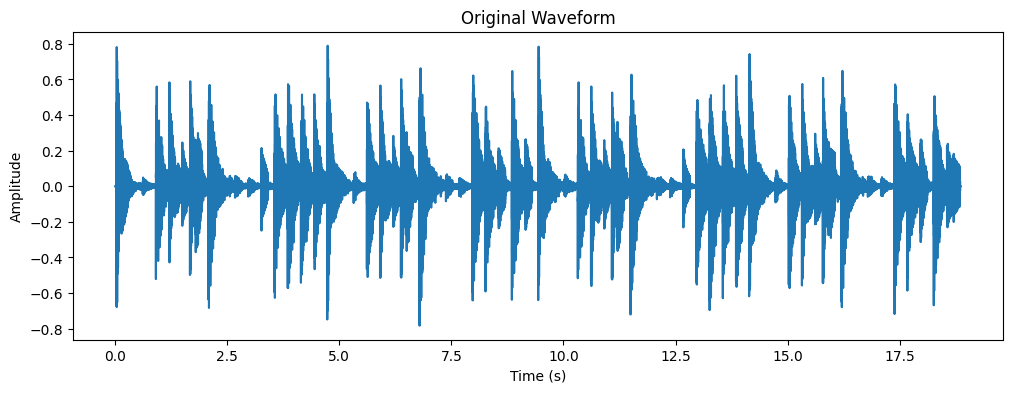

In [4]:
plt.figure(figsize=(12,4))
plt.plot(time, signal)
plt.title("Original Waveform")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.show()

# FFT AND PLOT FREQUENCY SPECTRUM

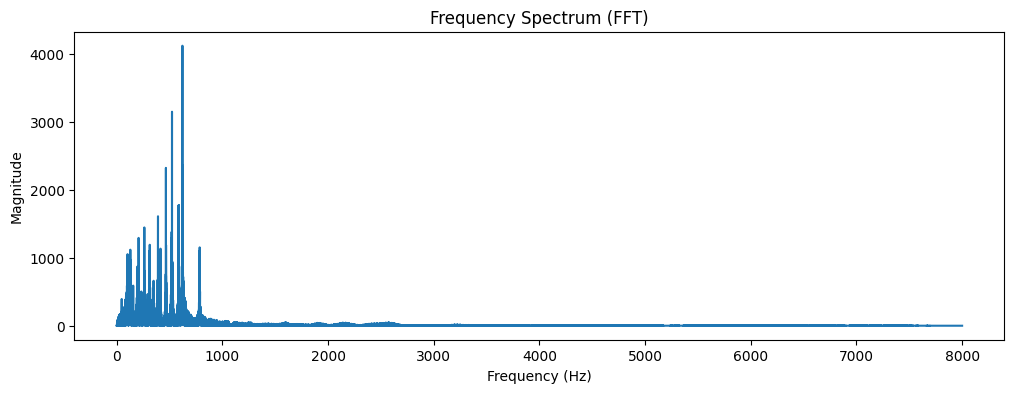

In [5]:
N = len(signal)
fft_vals = fft(signal)
fft_freq = fftfreq(N, 1/sr)
fft_vals = np.abs(fft_vals[:N//2])
fft_freq = fft_freq[:N//2]

plt.figure(figsize=(12,4))
plt.plot(fft_freq, fft_vals)
plt.title("Frequency Spectrum (FFT)")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")
plt.show()

In [6]:
dominant_indices = np.argsort(fft_vals)[-5:][::-1]
print("Top 5 Dominant Frequencies (Hz):")
for idx in dominant_indices:
    print(f"{fft_freq[idx]:.2f} Hz with magnitude {fft_vals[idx]:.2f}")

Top 5 Dominant Frequencies (Hz):
622.20 Hz with magnitude 4123.06
523.58 Hz with magnitude 3151.18
623.90 Hz with magnitude 2361.91
620.51 Hz with magnitude 2354.94
465.79 Hz with magnitude 2324.44


# FUNDAMENTAL FREQUENCY (F0) ESTIMATION

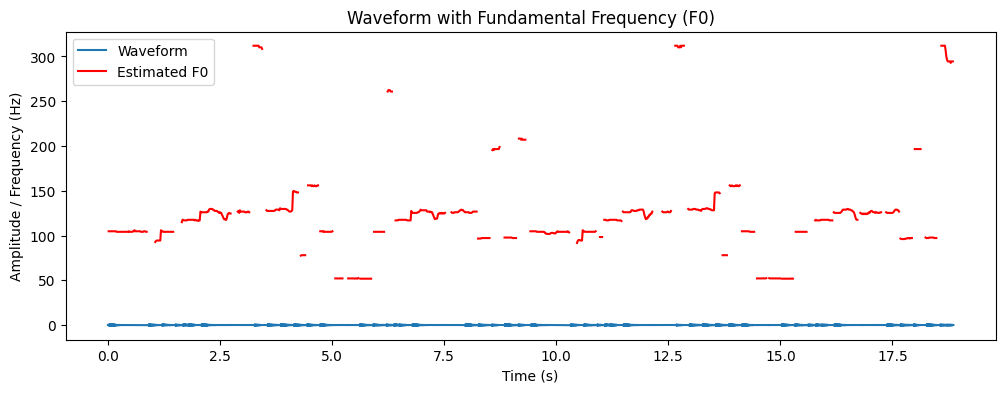

Estimated F0 (mean, ignoring NaNs): 123.07231087312428


In [7]:
f0, voiced_flag, voiced_probs = librosa.pyin(signal,fmin=50,fmax=500,sr=sr,frame_length=n_fft,hop_length=hop_length
)
f0_time = librosa.frames_to_time(np.arange(len(f0)), sr=sr, hop_length=hop_length)

plt.figure(figsize=(12,4))
plt.plot(time, signal, label="Waveform")
plt.plot(f0_time, f0, label="Estimated F0", color='r')
plt.title("Waveform with Fundamental Frequency (F0)")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude / Frequency (Hz)")
plt.legend()
plt.show()

print("Estimated F0 (mean, ignoring NaNs):", np.nanmean(f0))

In [8]:
f0_clean = f0[~np.isnan(f0)]
print(f"Fundamental Frequency (F0) statistics:")
print(f"Mean F0: {np.mean(f0_clean):.2f} Hz")
print(f"Min F0: {np.min(f0_clean):.2f} Hz")
print(f"Max F0: {np.max(f0_clean):.2f} Hz")

Fundamental Frequency (F0) statistics:
Mean F0: 123.07 Hz
Min F0: 51.76 Hz
Max F0: 312.03 Hz


# STFT AND SPECTROGRAM WITH WORD ANNOTATION

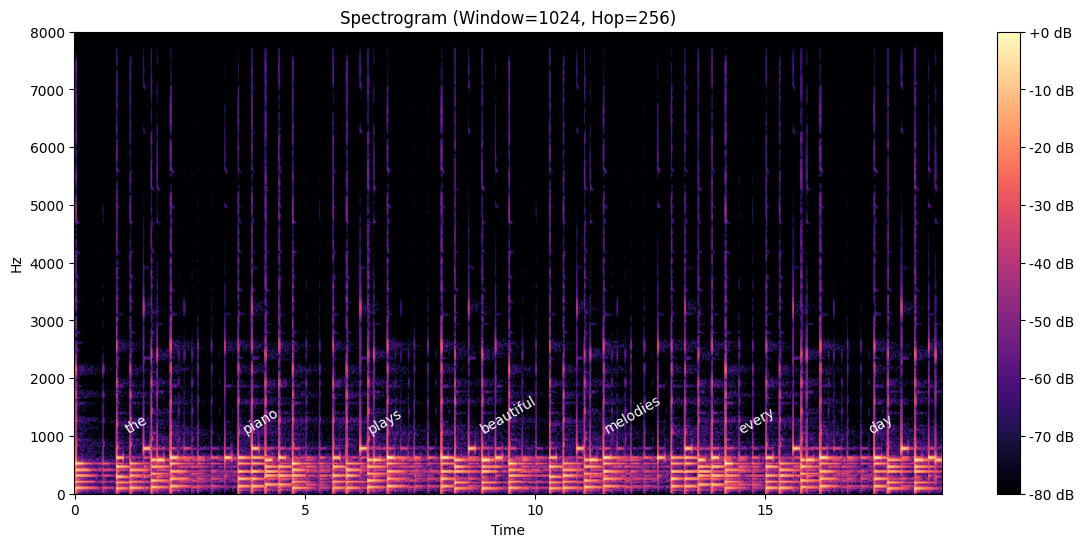

In [9]:
stft = librosa.stft(signal, n_fft=n_fft, hop_length=hop_length, window='hann')
stft_db = librosa.amplitude_to_db(np.abs(stft), ref=np.max)

plt.figure(figsize=(14,6))
librosa.display.specshow(stft_db,sr=sr,hop_length=hop_length,x_axis='time',y_axis='hz',cmap='magma'
)
plt.colorbar(format='%+2.0f dB')
plt.title(f"Spectrogram (Window={n_fft}, Hop={hop_length})")

word_times = np.linspace(0, duration, len(words)+1)
for i, word in enumerate(words):
    start_time = word_times[i]
    end_time = word_times[i+1]
    mid_time = (start_time + end_time)/2
    plt.text(mid_time, 1000, word, ha='center', va='bottom', color='white', fontsize=10, rotation=30)

plt.ylim(0, sr/2)
plt.show()